# Exercise 2: Optimization of Substrate Feed Concentration (SP)

**Goal:** Find the substrate feed concentration $S_P$ that maximises the production rate of $P$ under cyclic quasi-steady-state operation (10th cycle).

All processing conditions and timings are identical to Exercise 1 Part (b):
- Initiation: $F_I = 0.2$ L/h, $S_0 = 80$ g/L, $0 < t \leq 1$ h  
- Processing: $F_P = 0.5$ L/h, $S_P$ = **variable**, $t_I < t \leq t_I + 5$ h  
- Harvesting: $F_H = 2.5$ L/h, $t_P < t \leq t_P + 1$ h  
- Cycle time = 6 h, 10 complete cycles

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Parameters (unchanged from Exercise 1)

In [2]:
# Kinetic parameters
mu_max = 0.3    # h^{-1}
K_s    = 0.8    # g glucose / L
K_I    = 100    # g glucose / L
Y_XS   = 0.45   # g cells / g glucose
Y_XP   = 0.15   # g cells / g product

# Fixed feed / operating conditions
S0   = 80    # g glucose / L  (initiation feed concentration, fixed)
F_I  = 0.2   # L / h
F_P  = 0.5   # L / h
F_H  = 2.5   # L / h

# Initial conditions (same as Exercise 1)
V0     = 0.85   # L
X0     = 30.0   # g cells / L
S_init = 0.0    # g glucose / L (negligible)
P_init = 0.0    # g product / L

NX0 = X0 * V0
NS0 = S_init * V0
NP0 = P_init * V0
y0  = [NX0, NS0, NP0, V0]

## Growth-rate model (Haldane — uncompetitive substrate inhibition)

In [3]:
def mu_net(S):
    """Haldane specific growth rate accounting for uncompetitive substrate inhibition [h^-1]."""
    return mu_max * S / (K_s + S + S**2 / K_I)

## ODE system — parameterised by SP

The ODE system is identical to Exercise 1b except that the processing feed concentration
$S_P$ is now a free parameter rather than fixed at 80 g/L.

In [4]:
def make_odes(SP):
    """
    Return the ODE right-hand side for the multi-cycle fed-batch system
    with processing feed concentration SP [g glucose / L].
    """
    def odes(t, y):
        NX, NS, NP, V = y

        # Guard against numerical negatives
        V  = max(V,  1e-12)
        NX = max(NX, 0.0)
        NS = max(NS, 0.0)
        NP = max(NP, 0.0)

        X = NX / V
        S = NS / V
        P = NP / V

        mu = mu_net(S)

        # Phase logic
        if t <= 1.0:
            # Initiation
            F_in  = F_I
            S_in  = S0
            F_out = 0.0
        else:
            tau = (t - 1.0) % 6.0  # position within cycle (0-6 h)
            if tau < 5.0:
                # Processing
                F_in  = F_P
                S_in  = SP
                F_out = 0.0
            else:
                # Harvesting
                F_in  = 0.0
                S_in  = 0.0
                F_out = F_H

        dNXdt = mu * X * V        - F_out * X
        dNSdt = F_in * S_in       - (mu * X * V) / Y_XS - F_out * S
        dNPdt = (mu * X * V) / Y_XP                      - F_out * P
        dVdt  = F_in - F_out

        return [dNXdt, dNSdt, dNPdt, dVdt]

    return odes

## Helper: compute production rate for a given SP

In [5]:
def compute_production_rate(SP, n_cycles=10, rtol=1e-8, atol=1e-10):
    """
    Run the fed-batch simulation for n_cycles complete cycles and return
    the production rate [g/h] computed from the nth (last) cycle.

    Production rate = (NP at start of nth harvest - NP at end of nth harvest)
                      / cycle_time
    This is consistent with Exercise 1b methodology.
    """
    cycle_time = 6.0
    t_end  = 1.0 + n_cycles * cycle_time
    t_eval = np.linspace(0, t_end, 6000)

    sol = solve_ivp(
        make_odes(SP),
        (0, t_end),
        y0,
        method='BDF',       # BDF recommended by project sheet for stiff systems
        t_eval=t_eval,
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        return np.nan, sol

    t_arr  = sol.t
    NP_arr = sol.y[2]

    # Time bounds of the nth harvest step
    t_harvest_start = 1.0 + (n_cycles - 1) * cycle_time + 5.0
    t_harvest_end   = t_harvest_start + 1.0

    NP_before = np.interp(t_harvest_start, t_arr, NP_arr)
    NP_after  = np.interp(t_harvest_end,   t_arr, NP_arr)

    rate = (NP_before - NP_after) / cycle_time
    return rate, sol

## Sweep over SP values and find the optimum

In [6]:
# Test SP from 1 to 400 g glucose/L (80 points for resolution)
SP_values = np.linspace(1, 400, 80)

rates = []
for SP in SP_values:
    r, _ = compute_production_rate(SP)
    rates.append(r)

rates = np.array(rates)

# Identify optimum
idx_opt  = np.nanargmax(rates)
SP_opt   = SP_values[idx_opt]
rate_opt = rates[idx_opt]

print(f"Optimal SP            = {SP_opt:.1f} g glucose/L")
print(f"Maximum prod. rate    = {rate_opt:.3f} g/h")

Optimal SP            = 107.1 g glucose/L
Maximum prod. rate    = 132.102 g/h


## Plot: Production rate vs SP

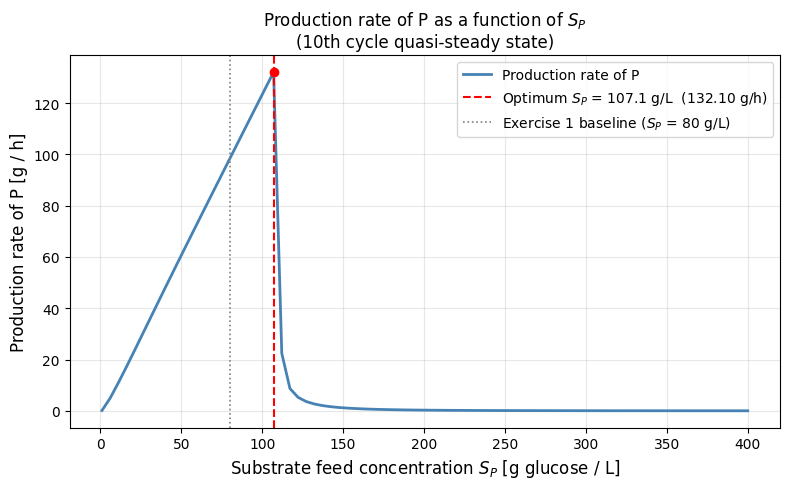

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(SP_values, rates, color='steelblue', linewidth=2, label='Production rate of P')
ax.axvline(SP_opt, color='red', linestyle='--', linewidth=1.5,
           label=f'Optimum $S_P$ = {SP_opt:.1f} g/L  ({rate_opt:.2f} g/h)')
ax.axvline(80, color='grey', linestyle=':', linewidth=1.2,
           label='Exercise 1 baseline ($S_P$ = 80 g/L)')
ax.scatter([SP_opt], [rate_opt], color='red', zorder=5)

ax.set_xlabel('Substrate feed concentration $S_P$ [g glucose / L]', fontsize=12)
ax.set_ylabel('Production rate of P [g / h]', fontsize=12)
ax.set_title('Production rate of P as a function of $S_P$\n(10th cycle quasi-steady state)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Concentration profiles at optimal SP

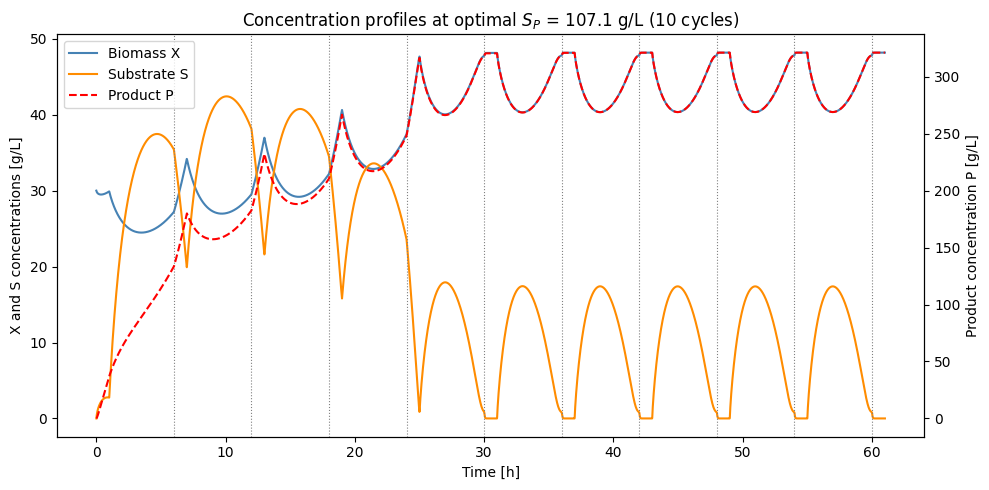

In [ ]:
_, sol_opt = compute_production_rate(SP_opt)

t_opt = sol_opt.t
NX_o, NS_o, NP_o, V_o = sol_opt.y

X_o = NX_o / V_o
S_o = NS_o / V_o
P_o = NP_o / V_o

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(t_opt, X_o, label='Biomass X', color='steelblue')
ax1.plot(t_opt, S_o, label='Substrate S', color='darkorange')
ax1.set_xlabel('Time [h]')
ax1.set_ylabel('X and S concentrations [g/L]')

ax2 = ax1.twinx()
ax2.plot(t_opt, P_o, linestyle='--', color='red', label='Product P')
ax2.set_ylabel('Product concentration P [g/L]')

for i in range(10):
    t_h = 1.0 + 5.0 + i * 6.0
    ax1.axvline(t_h, linestyle=':', linewidth=0.8, color='grey')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(f'Concentration profiles at optimal $S_P$ = {SP_opt:.1f} g/L (10 cycles)')
plt.tight_layout()
plt.show()

## Summary and discussion

In [9]:
rate_80, _ = compute_production_rate(80.0)

# Haldane optimum substrate concentration (analytical)
S_star = np.sqrt(K_s * K_I)

print("=" * 55)
print("EXERCISE 2 — RESULTS SUMMARY")
print("=" * 55)
print(f"Haldane mu_net peak at S*  = sqrt(Ks*KI) = {S_star:.1f} g/L")
print()
print(f"Optimal SP                 = {SP_opt:.1f} g glucose/L")
print(f"Maximum production rate    = {rate_opt:.3f} g/h")
print()
print(f"Baseline SP (Exercise 1)   = 80.0 g glucose/L")
print(f"Baseline production rate   = {rate_80:.3f} g/h")
print()
print(f"Improvement                = +{rate_opt - rate_80:.3f} g/h "
      f"({(rate_opt/rate_80 - 1)*100:.1f}%)")
print("=" * 55)
print()
print("Discussion — choice of SP:")
print("-" * 55)
print(f"The Haldane model predicts that mu_net is maximised at an"
      f" in-reactor concentration S* = {S_star:.1f} g/L.")
print(f"However, S inside the reactor is always lower than SP because")
print(f"cells consume glucose continuously. This means the optimal")
print(f"feed concentration ({SP_opt:.0f} g/L) must exceed S* significantly")
print(f"to keep the reactor near the Haldane optimum.")
print()
print("Under real conditions, SP will fluctuate. The rate-vs-SP curve")
print("shows a broad flat maximum: small deviations in SP from the optimum")
print("cause only minor losses in production rate. Therefore a practical")
print(f"choice is SP ~ {SP_opt:.0f} g/L, sitting near the plateau rather than")
print("the sharp peak, to ensure robustness against feed fluctuations.")

EXERCISE 2 — RESULTS SUMMARY
Haldane mu_net peak at S*  = sqrt(Ks*KI) = 8.9 g/L

Optimal SP                 = 107.1 g glucose/L
Maximum production rate    = 132.102 g/h

Baseline SP (Exercise 1)   = 80.0 g glucose/L
Baseline production rate   = 98.338 g/h

Improvement                = +33.764 g/h (34.3%)

Discussion — choice of SP:
-------------------------------------------------------
The Haldane model predicts that mu_net is maximised at an in-reactor concentration S* = 8.9 g/L.
However, S inside the reactor is always lower than SP because
cells consume glucose continuously. This means the optimal
feed concentration (107 g/L) must exceed S* significantly
to keep the reactor near the Haldane optimum.

Under real conditions, SP will fluctuate. The rate-vs-SP curve
shows a broad flat maximum: small deviations in SP from the optimum
cause only minor losses in production rate. Therefore a practical
choice is SP ~ 107 g/L, sitting near the plateau rather than
the sharp peak, to ensure rob